**CONTEXTO DEL PROBLEMA**

Sistema de recomendación de contenido (películas/experiencias):

Usuarios interactúan con contenido (ratings)
Contenido tiene metadata
Queremos predecir:
* rating
* recomendaciones personalizadas

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

# -------------------------
# USERS
# -------------------------
n_users = 500
users = pd.DataFrame({
    "user_id": np.arange(n_users),
    "age": np.random.randint(18, 65, n_users),
    "country": np.random.choice(["USA", "Peru", "Spain", "Mexico"], n_users),
    "device": np.random.choice(["mobile", "desktop", "tablet"], n_users)
})

# -------------------------
# ITEMS (contenido)
# -------------------------
n_items = 300
items = pd.DataFrame({
    "item_id": np.arange(n_items),
    "category": np.random.choice(["Action", "Drama", "Comedy", "Tech", "Travel"], n_items),
    "price": np.random.uniform(5, 100, n_items),
    "duration": np.random.randint(30, 180, n_items),
    "avg_rating": np.random.uniform(2.5, 5, n_items)
})

# Embeddings simulados (contenido tipo NLP)
embeddings = np.random.normal(0, 1, (n_items, 10))
emb_df = pd.DataFrame(embeddings, columns=[f"emb_{i}" for i in range(10)])

items = pd.concat([items, emb_df], axis=1)

# -------------------------
# INTERACCIONES
# -------------------------
n_interactions = 5000

interactions = pd.DataFrame({
    "user_id": np.random.choice(users.user_id, n_interactions),
    "item_id": np.random.choice(items.item_id, n_interactions),
    "rating": np.random.randint(1, 6, n_interactions),
    "timestamp": pd.date_range(start="2023-01-01", periods=n_interactions, freq="H")
})

# JOIN
data = interactions.merge(users, on="user_id").merge(items, on="item_id")

data.head()

/tmp/ipykernel_27230/2564013605.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "timestamp": pd.date_range(start="2023-01-01", periods=n_interactions, freq="H")


,user_id,item_id,rating,timestamp,age,country,device,category,price,duration,...,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9
0,46,97,3,2023-01-01 00:00:00,26,USA,mobile,Travel,26.426314,137,...,1.027695,0.320227,-0.906570,1.709386,-0.262556,0.364067,0.635381,0.357422,0.915417,1.073378
1,129,41,4,2023-01-01 01:00:00,52,Spain,desktop,Comedy,41.443165,128,...,-0.473458,0.628307,-1.166009,-0.071446,0.981314,1.235712,0.426496,-0.339045,-1.592601,-0.757550
2,351,138,5,2023-01-01 02:00:00,50,USA,tablet,Tech,95.397248,176,...,-1.030194,-0.038141,0.319401,0.129318,0.415065,-0.644046,1.152031,1.822169,-1.602676,-1.215598
3,465,282,2,2023-01-01 03:00:00,29,Mexico,desktop,Comedy,74.428800,160,...,-1.363542,0.419336,1.203537,0.343234,-0.115694,1.139613,-0.694319,-1.529833,-0.200598,0.535045
4,332,226,1,2023-01-01 04:00:00,34,Mexico,tablet,Drama,60.899200,133,...,-0.721416,-0.147807,1.112870,0.238481,-0.839320,1.354441,-1.428857,0.221884,-1.540086,0.252318


2. ANÁLISIS EXPLORATORIO (EDA)

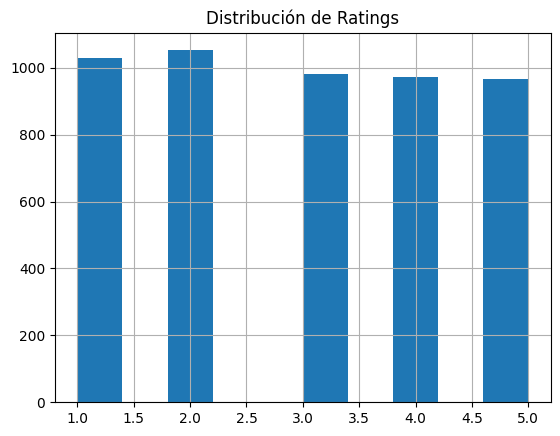

category
Action    2.928367
Comedy    2.926267
Drama     2.982983
Tech      3.027933
Travel    2.952298
Name: rating, dtype: float64
count    500.000000
mean      10.000000
std        3.102782
min        3.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       18.000000
Name: rating, dtype: float64
              rating     price  duration  avg_rating
rating      1.000000  0.009822  0.000359    0.000522
price       0.009822  1.000000 -0.032118    0.120717
duration    0.000359 -0.032118  1.000000   -0.026234
avg_rating  0.000522  0.120717 -0.026234    1.000000


In [3]:
import matplotlib.pyplot as plt

# Distribución de ratings
data['rating'].hist()
plt.title("Distribución de Ratings")
plt.show()

# Rating promedio por categoría
cat_rating = data.groupby("category")["rating"].mean()
print(cat_rating)

# Usuarios más activos
user_activity = data.groupby("user_id")["rating"].count()
print(user_activity.describe())

# Correlaciones
corr = data[["rating", "price", "duration", "avg_rating"]].corr()
print(corr)

**Insights típicos:**

* Sesgo hacia ratings altos
* Categorías con mayor engagement
* Usuarios heavy vs casual

 3.- PREPARACIÓN PARA DEEP LEARNING

  *  Encoding + normalización

In [4]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Label encoding
le_user = LabelEncoder()
le_item = LabelEncoder()
le_cat = LabelEncoder()

data['user_enc'] = le_user.fit_transform(data['user_id'])
data['item_enc'] = le_item.fit_transform(data['item_id'])
data['cat_enc'] = le_cat.fit_transform(data['category'])

# Normalización
scaler = MinMaxScaler()
data[['price', 'duration']] = scaler.fit_transform(data[['price', 'duration']])

# Features finales
features = [
    'user_enc', 'item_enc', 'cat_enc',
    'price', 'duration'
] + [f'emb_{i}' for i in range(10)]

X = data[features]
y = data['rating']

4. MODELO DE RECOMENDACIÓN (DEEP LEARNING)

Modelo híbrido:

*  Embeddings usuario/item
*  Features densas
*  Contenido (embeddings)

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model

n_users = data['user_enc'].nunique()
n_items = data['item_enc'].nunique()

# Inputs
user_input = Input(shape=(1,))
item_input = Input(shape=(1,))
other_input = Input(shape=(len(features)-2,))

# Embeddings
user_emb = Embedding(n_users, 50)(user_input)
item_emb = Embedding(n_items, 50)(item_input)

user_vec = Flatten()(user_emb)
item_vec = Flatten()(item_emb)

# Concatenación
x = Concatenate()([user_vec, item_vec, other_input])

# Red profunda
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

output = Dense(1)(x)

model = Model(inputs=[user_input, item_input, other_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     25,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │     15,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 113)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     14,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 64,961 (253.75 KB)

 Trainable params: 64,961 (253.75 KB)

 Non-trainable params: 0 (0.00 B)

5. ENTRENAMIENTO

In [6]:
X_user = data['user_enc']
X_item = data['item_enc']
X_other = data.drop(columns=['rating','user_id','item_id','user_enc','item_enc'])[features[2:]]

model.fit(
    [X_user, X_item, X_other],
    y,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.7140 - mae: 1.5845 - val_loss: 2.2771 - val_mae: 1.2820
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0904 - mae: 1.2419 - val_loss: 2.1443 - val_mae: 1.2632
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8651 - mae: 1.1728 - val_loss: 2.2663 - val_mae: 1.2830
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7420 - mae: 1.1236 - val_loss: 2.3449 - val_mae: 1.3027
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6583 - mae: 1.0898 - val_loss: 2.4331 - val_mae: 1.3211


6. EVALUACIÓN

In [7]:
loss, mae = model.evaluate([X_user, X_item, X_other], y)

print("MAE:", mae)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6906 - mae: 1.0925
MAE: 1.0925008058547974


**Métricas clave:**
* MAE (error absoluto)
* RMSE
* Precision@K (recomendaciones)
* Recall@K

7. GENERAR RECOMENDACIONES

In [11]:
def recommend(user_id, top_n=5):
    user_idx = le_user.transform([user_id])[0]

    all_items = np.arange(n_items)

    user_array = np.full_like(all_items, user_idx)

    other_features = np.zeros((len(all_items), X_other.shape[1]))

    preds = model.predict([user_array, all_items, other_features])

    top_items = preds.flatten().argsort()[-top_n:]

    return le_item.inverse_transform(top_items)

recommend(10)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([122, 123, 205, 290, 195])

8. ANÁLISIS DE RESULTADOS

Interpretación:

¿El modelo aprende preferencias?
¿Cold start?
¿Bias hacia categorías populares?

In [16]:
# Comparar pred vs real
preds = model.predict([X_user.values, X_item.values, X_other.values])

df_eval = pd.DataFrame({
    "real": y,
    "pred": preds.flatten()
})

df_eval.head()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,real,pred
0,3,3.719463
1,4,3.668437
2,5,3.075657
3,2,2.747264
4,1,2.877832


9. DOCUMENTACIÓN
* Arquitectura

Data Layer
 ├── Users
 ├── Items
 ├── Interactions

Feature Engineering
 ├── Encoding
 ├── Scaling
 ├── Embeddings

Model Layer
 ├── Deep Recommender (Hybrid)

Serving Layer
 ├── API (FastAPI)
 ├── Realtime inference

Monitoring
 ├── Drift
 ├── Performance